In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# case
import numpy as np
from utils.iea22s import IEA22s
from utils.sites import Hornsrev1Site

# this is a smoother version of PyWake IEA22 that works better with wake steering optimization
wt = IEA22s()
wds = np.arange(0, 360, 1)
wss = np.arange(3, 25, 1)
(x, y), site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
TI = 0.04  # site.local_wind().TI_ilk.ravel()s
n_threads = 1

In [3]:
# predict LUT
from utils.easy import easy_yaw_gnn

# work with ~PyWake-style inputs
yaws = easy_yaw_gnn(x, y, wd=wds, ws=wss, TI=TI, num_threads=n_threads, batch_size=2048)

/tmp/dgodi_4068900_hyd20251215/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Converting to graphs: 100%|██████████| 288/288 [00:00<00:00, 1168.01it/s]
INFO:utils.to_graph: generated 288 graphs from 288 cases


'generate_graphs | n=1 | 0.251 s | total=0 s'

'graph_maker_lut | n=1 | 0.256 s | total=0 s'

'predict_torchscript | n=1 | 0.495 s | total=0 s'

'torchscript_to_lut | n=1 | 0.001 s | total=0 s'

'easy_yaw_gnn | n=1 | 0.758 s | total=1 s'

In [4]:
# Report uplift
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=0, tilt=0, n_cpu=4)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=yaws, tilt=0, n_cpu=4)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift: {uplift:.2f}%")

8236.474840081231
8299.875561527422
AEP uplift: 0.77%


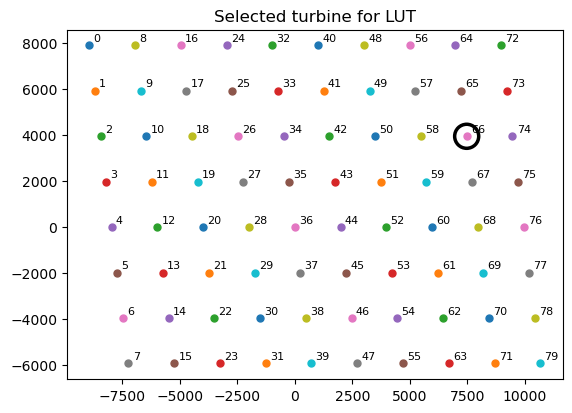

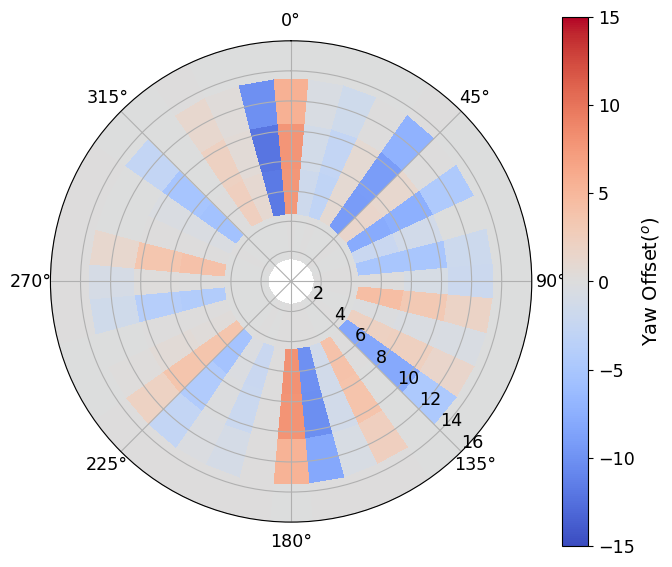

In [5]:
# plot look-up-table based on predictions
turbine_idx = int(66)  # select a turbine to plot

import matplotlib.pyplot as plt

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    x[turbine_idx],
    y[turbine_idx],
    marker="o",
    facecolors="none",
    edgecolors="k",
    linewidths=2.5,
    s=300,
)
plt.title('Selected turbine for LUT')
plt.show()

# Plot LUT for turbine_idx
from utils.plot_utils import lut_3d_heatmap

lut_3d_heatmap(yaws[turbine_idx, :, :], wds=wds, wss=wss)

In [6]:
# predict timeseries
n_t = 8760  # set ts to genereate
wdt = np.random.uniform(0, 360, n_t)
wst = np.random.uniform(3, 25, n_t)
# TI = np.random.uniform(0.02, 0.14, n_t)
TI = np.array(0.04)
num_threads = 1

In [11]:
# predict LUT
from utils.easy import easy_yaw_gnn

yaws_t = easy_yaw_gnn(
    x, y, wd=wdt, ws=wst, TI=TI, num_threads=n_threads, batch_size=2048, time=True
)

Converting to graphs: 100%|██████████| 8760/8760 [00:07<00:00, 1128.58it/s]
INFO:utils.to_graph: generated 8760 graphs from 8760 cases


'generate_graphs | n=3 | 7.767 s | total=278 s'

'graph_maker_time | n=2 | 7.776 s | total=273 s'

'predict_torchscript | n=3 | 10.084 s | total=288 s'

'easy_yaw_gnn | n=1 | 17.917 s | total=18 s'

In [13]:
# try yaw on PyWake
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wdt, ws=wst, TI=TI, yaw=0, tilt=0, n_cpu=4, time=True)
sim_gnn = wf_model(x=x, y=y, wd=wdt, ws=wst, TI=TI, yaw=yaws_t, tilt=0, n_cpu=4, time=True)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift: {uplift:.2f}%")

11439.37021753001
11483.825433806429
AEP uplift: 0.39%


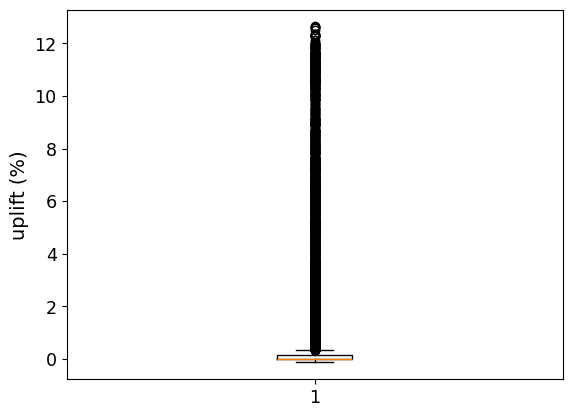

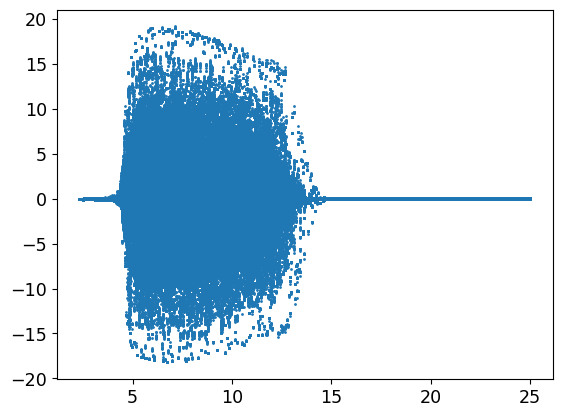

In [14]:
uplift = (sim_gnn.Power.sum("wt") - sim_base.Power.sum('wt')) / sim_base.Power.sum('wt')
plt.boxplot(100*uplift)
plt.ylabel('uplift (%)')
plt.show()
plt.scatter(sim_gnn.WS_eff.values, yaws_t, s=1)
plt.show()